# Setup

In [1]:
# importing main libs
import numpy as np
import pandas as pd

# libs for plots
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap
import matplotlib.colors as matcolors
from matplotlib.colors import LightSource
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.tools import mpl_to_plotly
from statsmodels.graphics.tsaplots import plot_acf

# utils
from dateutil import parser
import pprint as pp
from tqdm.notebook import tqdm

# statistical libs
from sklearn import preprocessing as prep
from scipy.stats import gaussian_kde

# models
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# unsupervised models
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

# filters
from scipy.ndimage import gaussian_filter, median_filter, uniform_filter
from scipy.ndimage import generic_filter
from skimage.filters import threshold_local, rank

# models (import)
from GAR.growth import calc_growth_rate
from GAR.partition import retropolated_PCA
from GAR.quantfit import run_quantfit
from GAR.tsfit import run_tsfit, get_cond_quant, select_df_partition
from GAR.scenario import run_scenario, gen_shocked_PCA
from GAR.historical import run_historical
from GAR.segment import run_segment
# from GAR.grid import gen_scenario_data, growth_horizons, qRegFit
# from GAR.grid import cond_quant_fits, select_x_list, gen_PDF_and_CDF

# # params
# sns.set(style='whitegrid')
# sns.set(rc={'figure.figsize':(4,4)})

# utils
pd.set_option('display.max_columns', None)

In [2]:
def label_points(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x']+.02, point['y'], str(point['val']))

In [3]:
def polytrend(series, level=1):
    index = series.reset_index().index
    z = np.polyfit(index, series, 2)
    p = np.poly1d(z)
    trend = p(index)
    return trend

# MVA
# partition[self.mapping['domestic_macro_MVA']] = partition[self.mapping['domestic_macro']].rolling(window=2).mean()
# partition.drop(columns=self.mapping['domestic_macro'], inplace=True)

class DataTransformer():
    def __init__(self):
        self.choice_columns = choice_columns
        self.mapping = t_mapping
    def transform(self, partition, depvar=None):
        
        # Lagged
        partition[self.mapping['leverage_L4']] = partition[self.mapping['leverage']].shift(4)
        partition[self.mapping['external_sector_L1']] = partition[self.mapping['external_sector']].shift(1)

        # Power
        # partition[reg_long] = partition[reg_short]**(n)

        # Diff
        partition[self.mapping['financial_conditions_diff']] = partition[self.mapping['financial_conditions']].diff(4)
        partition[self.mapping['housing_diff']] = partition[self.mapping['housing']].diff(4)
        partition[self.mapping['external_sector_diff']] = partition[self.mapping['external_sector']].diff(4)

        # Trend
        trend = polytrend(partition[self.mapping['intermediation']], 2)
        partition[self.mapping['intermediation_detrend']] = partition[self.mapping['intermediation']] - trend

         # ChangeRate
        # partition[reg_long] = partition[reg_short].pct_change(n)

        # Remove columns not in choice
        selected_columns = [value for key, value in self.mapping.items() if key in self.choice_columns]
        if type(depvar)!=type(None):
            partition = partition[['date', depvar] + selected_columns].copy()
        else:
            partition = partition[['date'] + selected_columns].copy()
        return partition

In [4]:
def poly_fit(x, y, max_degree=7, R2_tol=0.005):
    def lr_R2(degree):
        X = np.vander(x, degree+1)
        lr = LinearRegression(fit_intercept=False).fit(X, y)
        return lr, lr.score(X, y)

    best_model = None
    best_R2 = -float('inf')
    degree = 1
    while degree <= max_degree:
        lr, R2 = lr_R2(degree)
        improvement = R2 - best_R2
        if improvement < R2_tol:
            degree += 1
            lr, R2 = lr_R2(degree)
            improvement = R2 - best_R2
            if improvement < R2_tol:
                break
        best_R2 = R2
        best_model = lr
        degree += 1

    X = np.vander(x, len(best_model.coef_))
    return best_model.predict(X), best_model

In [5]:
def polynomial_equation(coefficients):
    # degree = len(coefficients) - 1
    equation = "x = "
    for i, coeff in enumerate(coefficients):
        if coeff == 0:
            continue
        if i == 0:
            equation += f"{coeff:.2f}"
        else:
            if coeff > 0:
                equation += f" + {coeff:.2f}y"
            else:
                equation += f" - {abs(coeff):.2f}y"

            if i > 1:
                equation += f"^{i}"
    return equation

In [6]:
# Setting up parameters

# Partition groups
autoregressive = ['real_y_ms_yoy']
financial_conditions = ['consumer_AMD', 'consumer_USD', 
                        'mortgage_AMD', 'mortgage_USD', 
                        'business_AMD', 'business_USD']
policy_conditions = ['tbill', 'gbond','policy_rate']
intermediation = ['loan_to_deposit', 'spread(loan-deposit)', 'spread(loan-tbill)']
housing = ['mortgage_stock_yoy', 'rep_yoy', 'rep_deviation']
leverage = ['credit_to_gdp_gap', 'household_credit_stock_yoy', 'business_credit_stock_yoy', 
            'npl', 'assets_equity']
external_sector = ['exchange_rate', 'net_tr_yoy', 'rus_y_yoy', 'copper_yoy_lag2', 'copper_yoy']

# global parmas
dict_global_params = {'target': 'real_y_ms', 'horizon':4}
dict_groups = {
    'autoregressive': autoregressive, 
    'financial_conditions': financial_conditions, 
    'policy_conditions':policy_conditions,
    'intermediation': intermediation, 
    'housing': housing,
    'leverage': leverage,
    'external_sector':external_sector
}

# assigning a color for each group
color_mapping = {
    'autoregressive':'#1f77b4', 'financial_conditions':'#ff7f0e', 
    'policy_conditions':'#2ca02c', 'intermediation':'#d62728',
    'housing':'#9467bd', 'leverage':'#8c564b', 'external_sector':'#e377c2',
    'real_y_ms':'purple'
}
target_group = {
    'real_y_ms':['real_y_ms']
}

# Data overview

## preview

In [9]:
panel_dataset = pd.read_csv('../data/panel_data/panel_dataset.csv', parse_dates=['date'])
panel_dataset = panel_dataset.set_index(['country', 'date'])

In [10]:
panel_dataset.describe()

,GDP_real_hz_4_growth,GDP_real_growth,CAR,CAR_T1,FX_PctC_4,REER,Unemployment_normalized,CPI_PctC_4,GDP_deflator_PctC_4,MPR_PctC_4,Lending_rate,Lending_rate_PctC_4,Lending_rate_sin,Deposit_rate,Deposit_rate_PctC_4,Deposit_rate_sin,Equity_index,Bond_yield_10Y,Bond_yield_5Y,Bond_yield_2Y,Bond_yield_1Y,Tbill_rate,MoneyMarket_rate,Gov_bond_rate,Corporate_bond_maturity,Syndicated_loan_maturity,ROA,ROE,Stocks_return,Stocks_volatility,Stocks_volatility_PctC_4,Stocks_trade_to_GDP_normalized,Stocks_cap_to_GDP_normalized,Stocks_turnover_normalized,NPL_ratio_PctC_4,Provisions/NPL_normalized,Interest_margin/Income,Non-interest_expenses/Income,Capital_T1/Assets_normalized,Liquid_asset_ratio_normalized,Current_ratio_normalized,Bank_assets_MC_PctC_4,Bank_assets_MC_cos,Bank_Loans_MC_PctC_4,Bank_liabilities_MC_PctC_4,Bank_currency_and_deposits_MC_PctC_4,Bank_currency_and_deposits_MC_cos,Nominal_house_price,Nominal_house_price_PctC_4,Real_house_price,Real_house_price_PctC_4,Rent_price_PctC_4,Price_to_income_ratio,Price_to_rent_ratio,RRE_Loans_MC_PctC_4,CRE_Loans_MC_PctC_4,CRE/Loans_normalized,RRE/Loans_normalized,IIP_assets_PctC_4,IIP_liabilities_PctC_4,Direct_investment_liabilities_PctC_4,Portfolio_investment_liabilities_PctC_4,Import_Merchandise_Price,Import_Merchandise_Price_PctC_4,MPI,MPI_capital,MPI_CCyB
count,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000
mean,2.233827,2.855715,16.446298,14.047932,0.015991,97.770185,0.438018,0.035280,0.039114,-0.062764,9.541933,-0.059716,-0.433110,4.032576,0.016848,-0.068862,103.670133,5.647054,5.668188,4.875087,4.516840,4.112204,3.721454,5.581948,9.307232,6.033990,1.253106,10.314645,6.016542,20.594178,0.021408,0.365681,0.424131,0.359430,0.024200,0.437322,59.604904,57.859143,0.514708,0.463074,0.462921,0.090973,-0.198858,0.103279,0.451496,0.090288,-0.241215,88.452149,0.061391,101.142720,0.026063,0.043918,109.503115,102.871274,0.130137,0.123574,0.463651,0.452994,0.110285,0.099489,0.183012,0.816653,0.992483,0.009370,1.120139,0.310417,0.019097
std,4.365419,3.803459,3.523318,3.791416,0.149446,9.019720,0.274897,0.039292,0.040037,0.775577,7.491301,0.186154,0.523007,3.768561,0.716158,0.618241,45.033353,3.539088,5.132605,4.378071,4.042349,3.744546,4.070853,3.545901,9.542000,2.262887,1.502681,14.460563,22.215067,8.861110,0.253365,0.305683,0.291784,0.295852,0.389119,0.279182,18.242464,17.915806,0.271525,0.262113,0.262278,0.144737,0.629901,0.157575,5.585738,0.121343,0.632632,25.147699,0.099976,19.442495,0.096311,0.072444,20.079923,17.380474,0.236151,0.240685,0.291502,0.273635,0.214994,0.212182,0.706741,8.308151,0.140220,0.103708,1.879159,0.673130,0.182558
min,-23.367205,-19.789577,-2.889515,-3.642995,-2.529294,49.200837,-0.107666,-0.037502,-0.130464,-10.499042,-1.708829,-0.900527,-2.667644,-1.890782,-8.125000,-3.796054,2.172761,-1.078487,-5.671472,-4.358343,-4.080308,-4.630416,-5.149730,-1.511541,-18.894253,-5.067304,-23.531623,-276.837644,-74.562450,2.392925,-0.900339,-0.477741,-0.196902,-0.295032,-1.834743,-0.342682,-500.672411,-441.028104,-0.175275,-0.061088,-0.147311,-0.396894,-1.697202,-0.363371,-9.833325,-0.402946,-1.710748,-35.342776,-0.902563,8.393480,-1.107646,-0.890578,15.056529,36.666150,-2.849540,-1.970858,-2.577010,-0.774597,-0.286423,-0.294381,-0.677161,-8.79961

In [11]:
panel_dataset.loc['Armenia'].describe()

,GDP_real_hz_4_growth,GDP_real_growth,CAR,CAR_T1,FX_PctC_4,REER,Unemployment_normalized,CPI_PctC_4,GDP_deflator_PctC_4,MPR_PctC_4,Lending_rate,Lending_rate_PctC_4,Lending_rate_sin,Deposit_rate,Deposit_rate_PctC_4,Deposit_rate_sin,Equity_index,Bond_yield_10Y,Bond_yield_5Y,Bond_yield_2Y,Bond_yield_1Y,Tbill_rate,MoneyMarket_rate,Gov_bond_rate,Corporate_bond_maturity,Syndicated_loan_maturity,ROA,ROE,Stocks_return,Stocks_volatility,Stocks_volatility_PctC_4,Stocks_trade_to_GDP_normalized,Stocks_cap_to_GDP_normalized,Stocks_turnover_normalized,NPL_ratio_PctC_4,Provisions/NPL_normalized,Interest_margin/Income,Non-interest_expenses/Income,Capital_T1/Assets_normalized,Liquid_asset_ratio_normalized,Current_ratio_normalized,Bank_assets_MC_PctC_4,Bank_assets_MC_cos,Bank_Loans_MC_PctC_4,Bank_liabilities_MC_PctC_4,Bank_currency_and_deposits_MC_PctC_4,Bank_currency_and_deposits_MC_cos,Nominal_house_price,Nominal_house_price_PctC_4,Real_house_price,Real_house_price_PctC_4,Rent_price_PctC_4,Price_to_income_ratio,Price_to_rent_ratio,RRE_Loans_MC_PctC_4,CRE_Loans_MC_PctC_4,CRE/Loans_normalized,RRE/Loans_normalized,IIP_assets_PctC_4,IIP_liabilities_PctC_4,Direct_investment_liabilities_PctC_4,Portfolio_investment_liabilities_PctC_4,Import_Merchandise_Price,Import_Merchandise_Price_PctC_4,MPI,MPI_capital,MPI_CCyB
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,6.000000e+01,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.0
mean,4.136005,5.320232,22.664429,20.620969,0.011226,97.817062,0.415897,0.038048,0.058891,0.069614,16.581047,-0.026864,-6.337233e-01,8.897758,0.058908,-0.349338,101.630353,9.777899,11.994550,10.280669,8.740733,8.055289,6.881402,10.272038,5.360812,6.066342,1.937384,9.926045,11.410544,25.239894,0.014564,0.571389,0.514843,0.534201,0.100884,0.453773,61.657014,58.320196,0.393058,0.380004,0.541397,0.221437,-0.408089,0.245405,4.572227,0.182582,-0.436346,61.263370,0.132495,93.008631,0.087582,0.083916,119.114280,89.441492,0.247278,0.222485,0.411668,0.535303,0.136146,0.129359,0.102950,1.932754,1.036624,0.021733,0.716667,0.133333,0.0
std,7.774475,7.167235,6.818832,6.970112,0.099622,7.404024,0.364694,0.031723,0.028740,0.249506,2.055184,0.079604,2.451381e-01,2.221666,0.193796,0.564133,35.100889,3.141812,4.012204,3.123541,2.892804,2.441363,2.830311,3.297779,9.209391,1.515798,1.307358,5.777014,23.453155,7.311169,0.199654,0.117324,0.149868,0.157069,0.437507,0.271281,5.974208,5.352418,0.328266,0.248505,0.243087,0.108822,0.470931,0.131713,3.311667,0.078921,0.505779,21.048701,0.120156,20.951003,0.109423,0.054103,15.715991,13.538978,0.173420,0.141623,0.152246,0.220333,0.151984,0.127462,0.183121,5.706944,0.087627,0.068702,1.403285,0.566484,0.0
min,-19.789577,-19.789577,14.499379,12.686905,-0.196909,77.381347,0.000000,-0.020395,0.004309,-0.354839,11.672504,-0.238409,-9.938836e-01,5.335546,-0.297122,-0.999999,31.381506,4.177257,4.998021,4.707922,3.425270,3.708478,2.695082,4.910700,-11.536838,3.464461,-0.496003,-3.488330,-40.183607,10.144319,-0.377168,0.308387,0.214405,0.192052,-0.533363,0.000000,48.981854,48.969744,0.009758,0.000000,0.000000,0.013500,-0.999003,-0.028907,-3.638183,0.005475,-1.249121,11.185876,-0.126732,45.081370,-0.143155,-0.030676,83.777271,55.320068,-0.013257,-0.015809,0.023162,0.000000,-0.173122,-0.109841,-0.421134,-1.472363,0.848515,-0.124755,-2.000000,-1.000000,0.0
25%,2.035814,2.931209,17.265776,15.152539,-0.014407,95.593908,0.063779,0.017015,0.039384,-0.083333,16.202568,-0.074097,

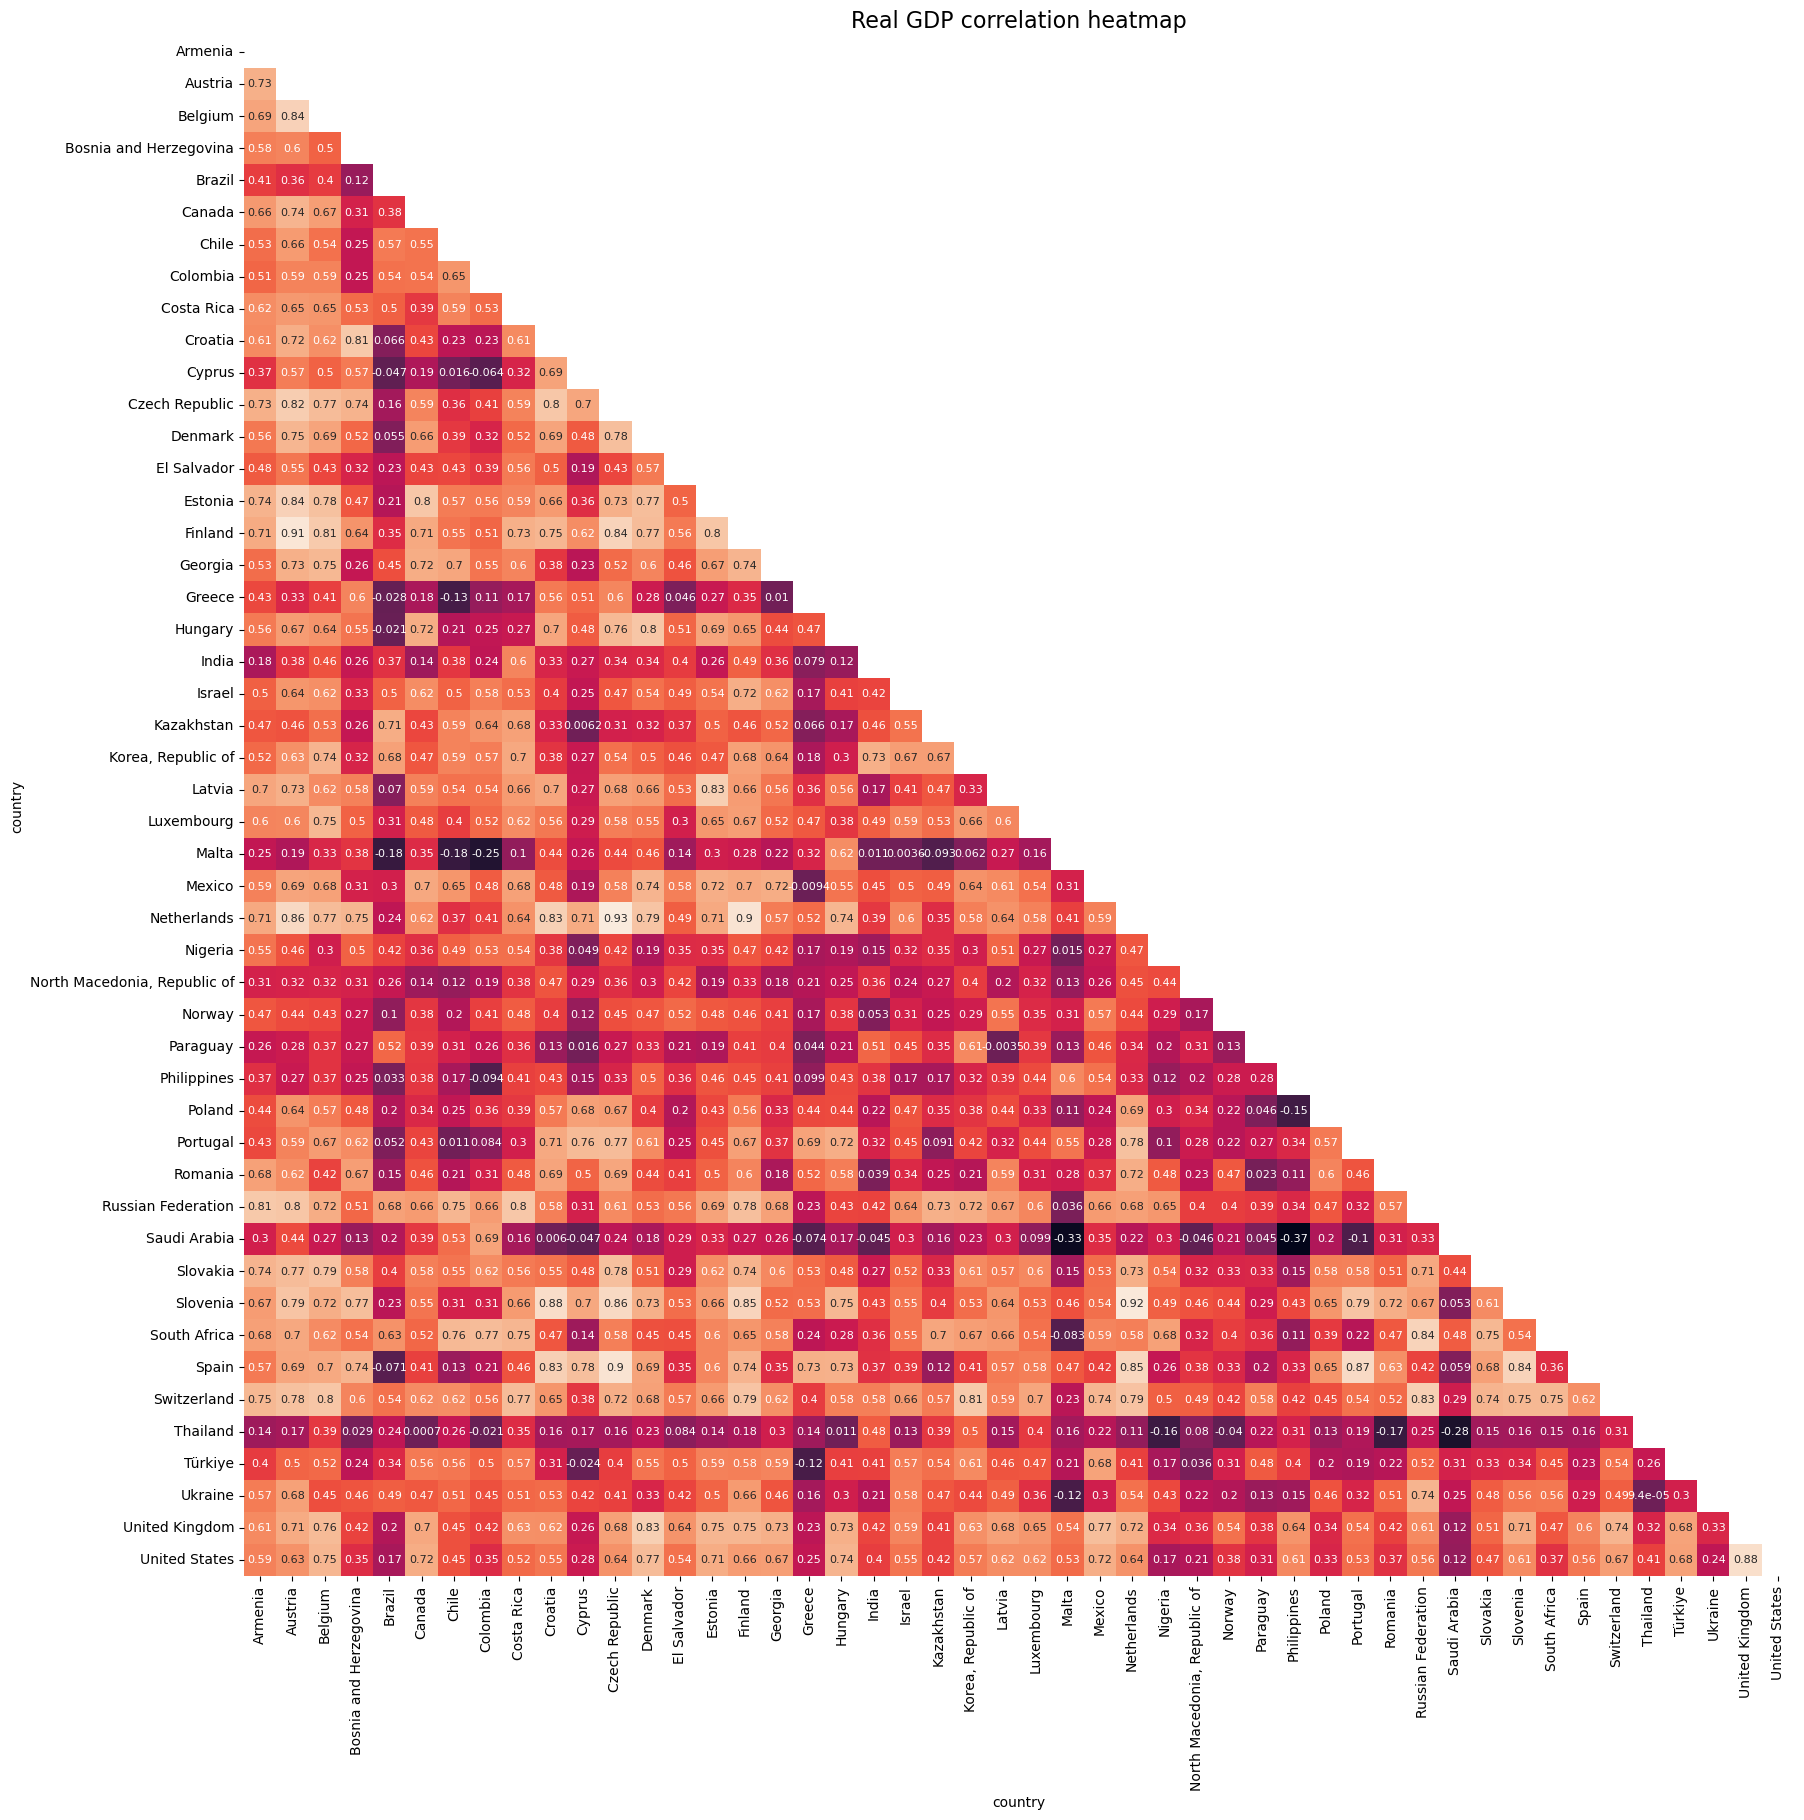

In [21]:
# Real GDP correlation heatmap across countires
gdp_real_corr = panel_dataset['GDP_real_growth'].unstack('country').corr()
mask = np.triu(gdp_real_corr)
fig, ax = plt.subplots(figsize=(20, 20))
ax = sns.heatmap(gdp_real_corr, annot=True, ax=ax, cbar=False, annot_kws={"size": 8}, mask=mask)
ax.set_title('Real GDP correlation heatmap', fontsize=16)
plt.show()

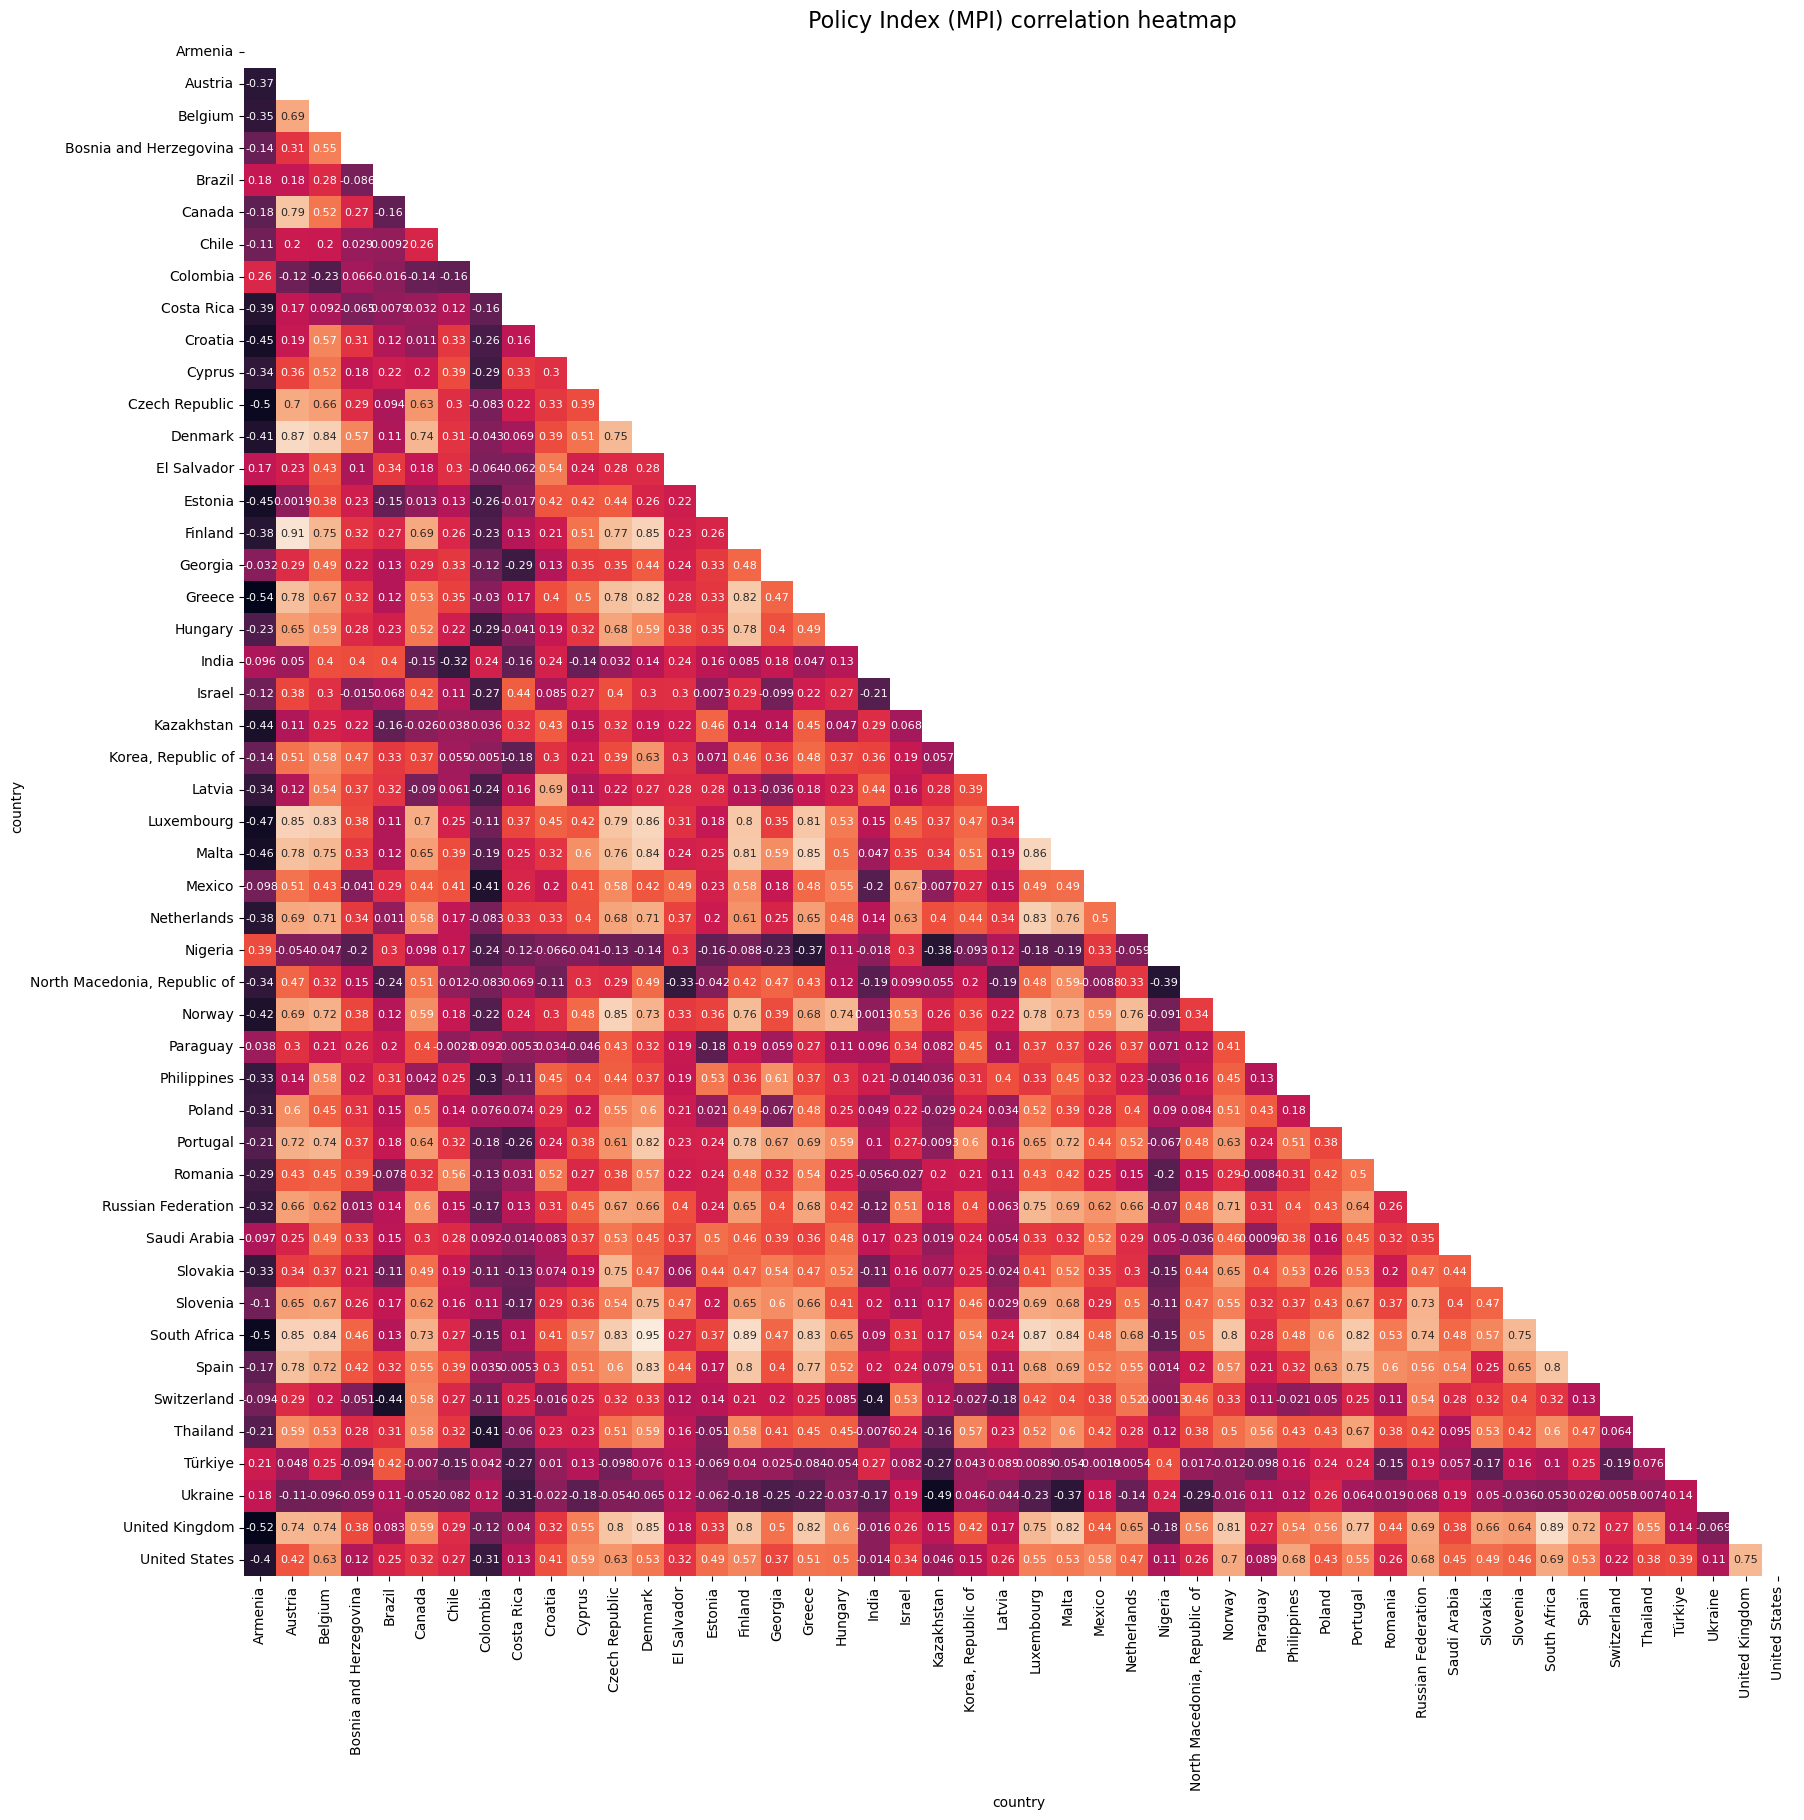

In [22]:
# Monetary Policy Index (MPI) correlation heatmap across countires
mpi_corr = panel_dataset['MPI'].unstack('country').corr()
mask = np.triu(mpi_corr)
fig, ax = plt.subplots(figsize=(20, 20))
ax = sns.heatmap(mpi_corr, annot=True, ax=ax, cbar=False, annot_kws={"size": 8}, mask=mask)
ax.set_title(' Policy Index (MPI) correlation heatmap', fontsize=16)
plt.show()

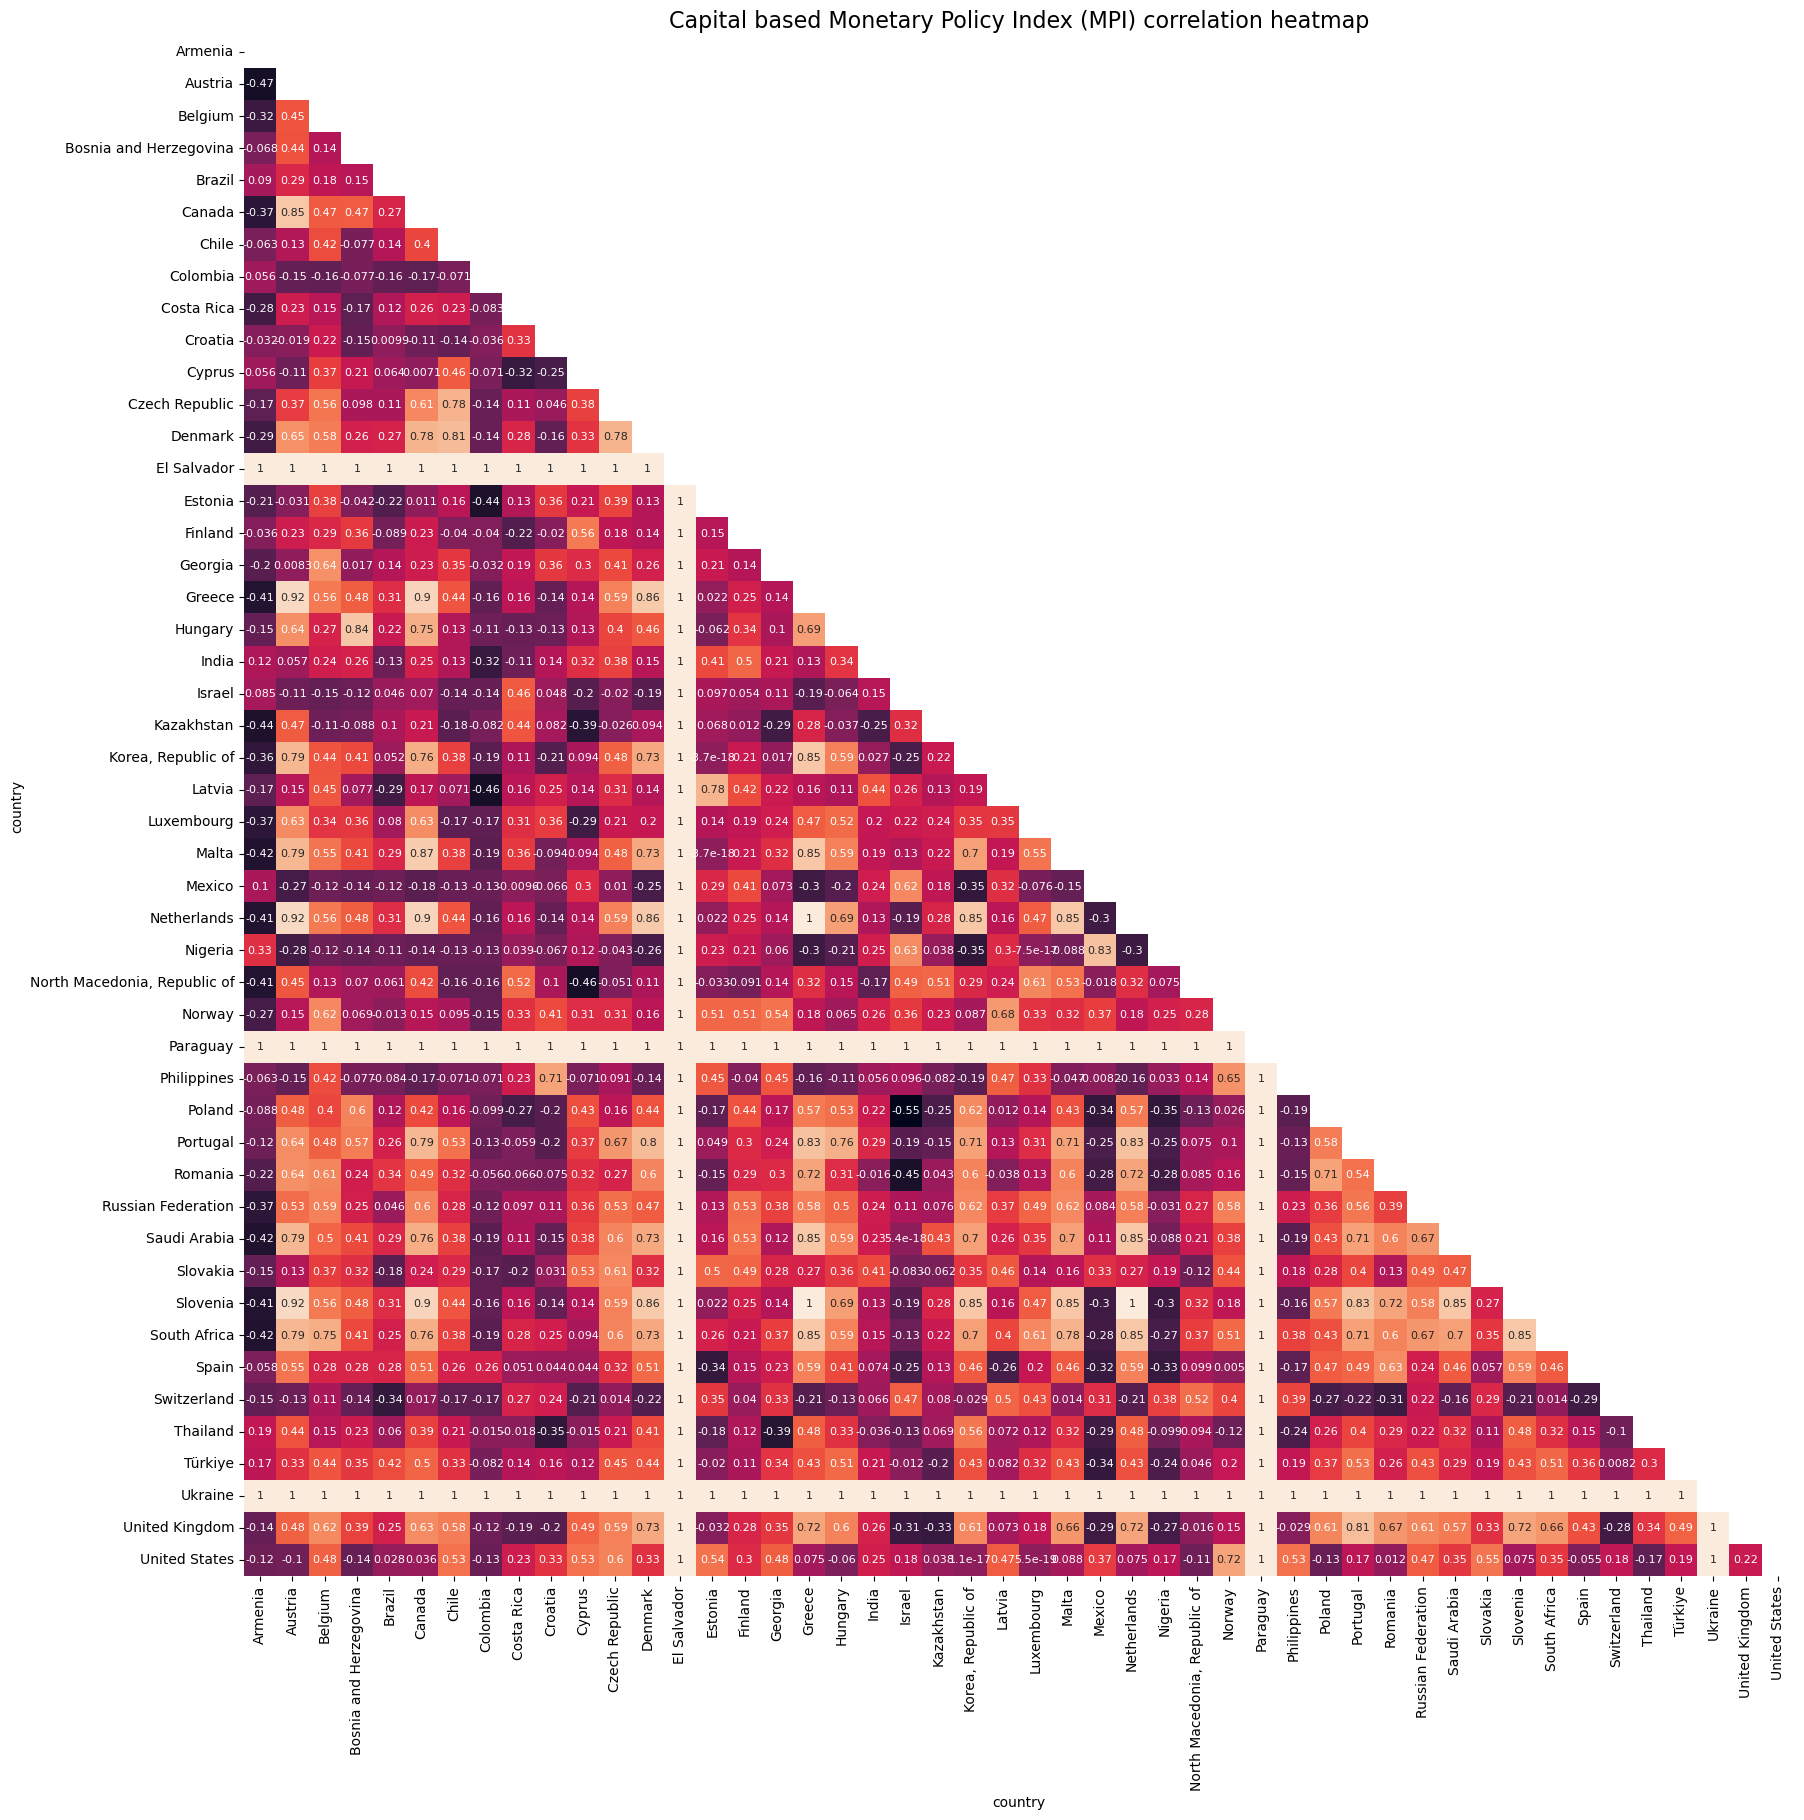

In [15]:
# Capital based Monetary Policy Index (MPI) correlation heatmap across countires
mpi_capital_corr = panel_dataset['MPI_capital'].unstack('country').corr().fillna(1)
mask = np.triu(mpi_capital_corr)
fig, ax = plt.subplots(figsize=(20, 20))
ax = sns.heatmap(mpi_capital_corr, annot=True, ax=ax, cbar=False, annot_kws={"size": 8}, mask=mask)
ax.set_title('Capital based Monetary Policy Index (MPI) correlation heatmap', fontsize=16)
plt.show()

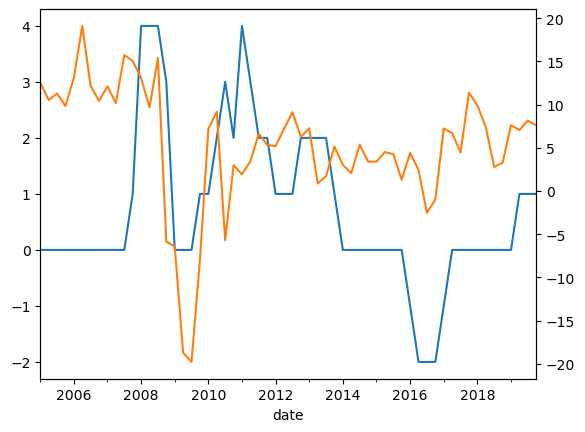

In [23]:
panel_dataset.loc['Armenia', 'MPI'].plot()
panel_dataset.loc['Armenia', 'GDP_real_growth'].plot(secondary_y=True)
plt.show()

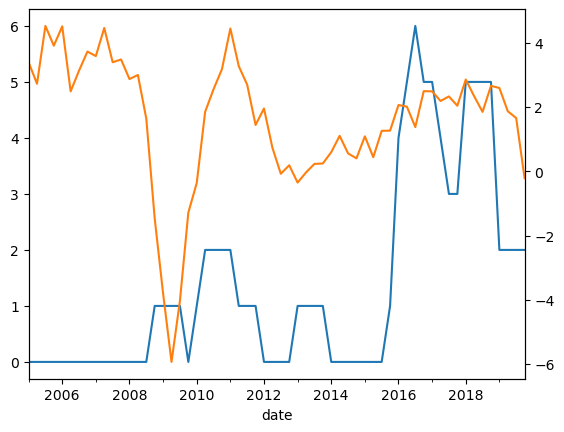

In [24]:
panel_dataset.loc['Austria', 'MPI'].plot()
panel_dataset.loc['Austria', 'GDP_real_growth'].plot(secondary_y=True)
plt.show()

## GDP growth trends

In [38]:
# preparing the dataset
panel_regressors = panel_dataset.copy()
scaler = lambda x: prep.StandardScaler().fit(x.values[:, np.newaxis])
transformers = panel_regressors.groupby('country').agg(scaler)
scale = lambda x: transformers.loc[x.index[0][0], x.name].transform(x.values[:, np.newaxis]).ravel()
inverse_scale = lambda x: transformers.loc[x.index[0][0], x.name].inverse_transform(x.values[:, np.newaxis]).ravel()
panel_regressors_scaled = panel_regressors.groupby('country').transform(scale)

In [39]:
gdp_growth_mean = panel_regressors['GDP_real_hz_4_growth'].groupby('country').mean().rename('mean')
gdp_growth_std = panel_regressors['GDP_real_hz_4_growth'].groupby('country').std().rename('std')
gdp_growth_moments = pd.concat([gdp_growth_mean, gdp_growth_std], axis=1)

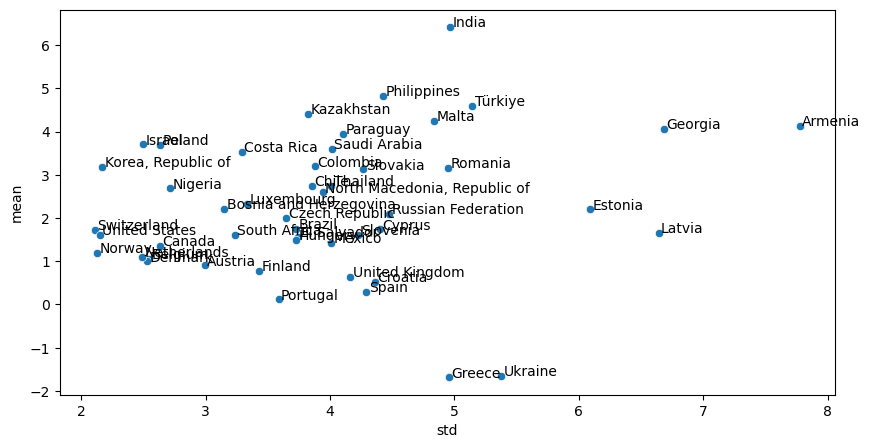

In [40]:
# plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax = sns.scatterplot(data=gdp_growth_moments, x='std', y='mean', ax=ax)
labels = pd.Series(gdp_growth_moments.index, index=gdp_growth_moments.index)
label_points(gdp_growth_moments['std'], gdp_growth_moments['mean'], labels, ax)
plt.show()

# Modeling

## Panel quantile regression

In [7]:
# preparing the dataset
panel_dataset = pd.read_csv('../data/panel_data/panel_dataset.csv', parse_dates=['date'])
panel_dataset = panel_dataset.set_index(['country', 'date'])
panel_regressors = panel_dataset.copy()
scaler = lambda x: prep.StandardScaler().fit(x.values[:, np.newaxis])
transformers = panel_regressors.groupby('country').agg(scaler)
scale = lambda x: transformers.loc[x.index[0][0], x.name].transform(x.values[:, np.newaxis]).ravel()
inverse_scale = lambda x: transformers.loc[x.index[0][0], x.name].inverse_transform(x.values[:, np.newaxis]).ravel()
panel_regressors_scaled = panel_regressors.groupby('country').transform(scale)

In [8]:
# OLS fit
target = 'GDP_real_hz_4_growth'
y = panel_regressors[target]
X = panel_regressors.drop(columns=target)
use_cols = [
    'GDP_real_growth', 'MPI', 
    'CAR', 'REER', 'Unemployment_normalized', 
    'CPI_PctC_4', 'Equity_index',
    'MoneyMarket_rate', 'Corporate_bond_maturity',
    'Stocks_return', 'NPL_ratio_PctC_4'
]
# X = X[use_cols].copy()
olsRes = sm.OLS(y, X).fit()

# quantile regression fit
qRes_50 = sm.QuantReg(y, X).fit(q=0.5, max_iter=1000, p_tol=1e-06)
qRes_10 = sm.QuantReg(y, X).fit(q=0.1, max_iter=1000, p_tol=1e-06)

In [9]:
print('OLS r2:', olsRes.rsquared_adj.round(3))
print('Q(0.5) p-r2:', qRes_50.prsquared.round(3))
print('Q(0.1) p-r2:', qRes_10.prsquared.round(3))

OLS r2: 0.587
Q(0.5) p-r2: 0.278
Q(0.1) p-r2: 0.373


In [10]:
# predictions vs actual
# actual
y_actual = panel_regressors[target].copy()

# prediction ols
y_hat_ols = olsRes.predict(X)
y_hat_ols.index = panel_regressors.index
y_hat_ols.name = target
# y_hat_ols = pd.DataFrame(y_hat_ols).transform(inverse_scale)[target]
y_hat_ols.name = target+'_pred_ols'

# prediction quantile reg (0.5)
y_hat_qr50 = qRes_50.predict(X)
y_hat_qr50.index = panel_regressors.index
y_hat_qr50.name = target
# y_hat_qr50 = pd.DataFrame(y_hat_qr50).transform(inverse_scale)[target]
y_hat_qr50.name = target+'_pred_qr50'

# prediction quantile reg (0.1)
y_hat_qr10 = qRes_10.predict(X)
y_hat_qr10.index = panel_regressors.index
y_hat_qr10.name = target
# y_hat_qr10 = pd.DataFrame(y_hat_qr10).transform(inverse_scale)[target]
y_hat_qr10.name = target+'_pred_qr10'

# combining the panel predictions
panel_pred_qr = pd.concat([y_hat_qr50, y_hat_qr10], axis=1)
panel_pred_qr = panel_pred_qr.reset_index().set_index(['country', 'date'])

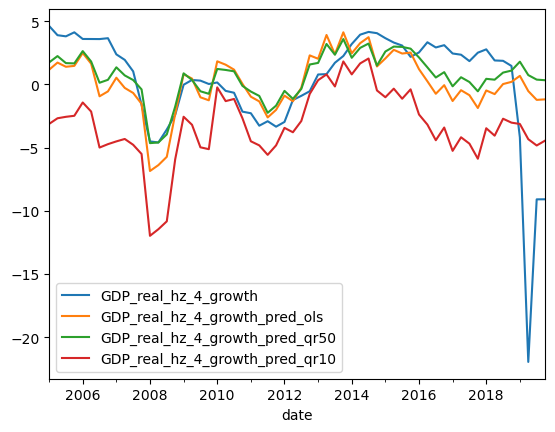

In [11]:
c = 'Spain'
y_actual.loc[c].plot()
y_hat_ols.loc[c].plot()
y_hat_qr50.loc[c].plot()
y_hat_qr10.loc[c].plot()
plt.legend()
plt.show()

In [12]:
# saving results
wd_path = "../data/results/"
panel_dataset_forecasts = pd.concat([panel_dataset, panel_pred_qr], axis=1)
panel_dataset_forecasts.to_csv(wd_path+'panel_dataset_forecasts.csv')

## Individual regressions

In [13]:
# # preparing the dataset
# panel_regressors = panel_dataset.drop(columns=['GDP'])
# base_target = 'GDP_real'
# horizon = 4
# target = base_target+'_hz_'+str(horizon)+'_growth'
# autoregressive = base_target+'_growth'

# # adding GDP growth rate
# bt_growth_series = panel_regressors[base_target].groupby('country')
# panel_regressors[autoregressive] = bt_growth_series.pct_change(4)*100
# bt_growth_series = bt_growth_series.apply(calc_growth_rate, horizon=4, yearfreq=4, method_growth='cpd')
# panel_regressors[target] = bt_growth_series.reset_index(0, drop=True)
# panel_regressors = panel_regressors.drop(columns=base_target)
# panel_regressors = panel_regressors.dropna(subset=[target, autoregressive])

# # standardising series
# scaler = lambda x: prep.StandardScaler().fit(x.values[:,np.newaxis])
# transformers = panel_regressors.groupby('country').agg(scaler)
# scale = lambda x: transformers.loc[x.index[0][0], x.name].transform(x.values[:,np.newaxis]).ravel()
# inverse_scale = lambda x: transformers.loc[x.index[0][0], x.name].inverse_transform(x.values[:,np.newaxis]).ravel()
# panel_regressors_scaled = panel_regressors.copy()
# # panel_regressors_scaled = panel_regressors.groupby('country').transform(scale)

# Frontier approach

## optimal lag

In [83]:
year = '2010'
country = 'Armenia'
q_names = {
    'GDP_real_hz_4_growth_pred_qr10': 'GDPq10',
    'GDP_real_hz_4_growth_pred_qr50': 'GDPq50',
}
frontier_data = panel_pred_qr.copy()
frontier_data.rename(columns=q_names, inplace=True)
frontier_data['GAP'] = frontier_data['GDPq50'] - frontier_data['GDPq10']
frontier_data.drop(columns='GDPq10', inplace=True)

# creating leads for GDPq50 
frontier_data['GDPq50_1y'] = frontier_data.groupby(['country'])['GDPq50'].shift(4)
frontier_data['GDPq50_2y'] = frontier_data.groupby(['country'])['GDPq50'].shift(8)
frontier_data['GDPq50_3y'] = frontier_data.groupby(['country'])['GDPq50'].shift(12)
frontier_data['GDPq50_4y'] = frontier_data.groupby(['country'])['GDPq50'].shift(16)

# creating leads for GAP
frontier_data['GAP_1y'] = frontier_data.groupby(['country'])['GAP'].shift(4)
frontier_data['GAP_2y'] = frontier_data.groupby(['country'])['GAP'].shift(8)
frontier_data['GAP_3y'] = frontier_data.groupby(['country'])['GAP'].shift(12)
frontier_data['GAP_4y'] = frontier_data.groupby(['country'])['GAP'].shift(16)

# estimation of GDPq50 growth rates for different horizons
for horizon in [4, 8, 12, 16]:
    gdp_hz_i = (frontier_data['GDPq50']/100).groupby('country').rolling(window=horizon+1)
    gdp_hz_i = gdp_hz_i.apply(lambda x: np.prod(x.iloc[::4]+1)-1)*100
    frontier_data[f'GDPq50_hz_{horizon+4}'] = gdp_hz_i.reset_index(0, drop=True)

In [85]:
frontier_data.corr()

,GDPq50,GAP,GDPq50_1y,GDPq50_2y,GDPq50_3y,GDPq50_4y,GAP_1y,GAP_2y,GAP_3y,GAP_4y,GDPq50_hz_8,GDPq50_hz_12,GDPq50_hz_16,GDPq50_hz_20
GDPq50,1.000000,-0.232413,0.520586,0.277149,0.266207,0.295858,-0.107140,-0.012151,-0.047893,0.009983,0.870641,0.742974,0.665089,0.703339
GAP,-0.232413,1.000000,0.094081,0.211897,0.156830,0.072314,0.413076,0.256752,0.242346,0.122690,-0.075265,0.028310,0.076099,0.070673
GDPq50_1y,0.520586,0.094081,1.000000,0.521727,0.282118,0.267516,-0.188594,-0.093483,-0.011554,-0.028065,0.872913,0.848745,0.756281,0.695737
GDPq50_2y,0.277149,0.211897,0.521727,1.000000,0.522037,0.275347,0.119221,-0.187103,-0.099497,-0.001621,0.462328,0.768414,0.774914,0.720830
GDPq50_3y,0.266207,0.156830,0.282118,0.522037,1.000000,0.518679,0.220742,0.121944,-0.195729,-0.099445,0.321021,0.462488,0.720252,0.751725
GDPq50_4y,0.295858,0.072314,0.267516,0.275347,0.518679,1.000000,0.166560,0.223831,0.118901,-0.191819,0.320026,0.350819,0.456964,0.680046
GAP_1y,-0.107140,0.413076,-0.188594,0.119221,0.220742,0.166560,1.000000,0.375753,0.227874,0.210525,-0.167287,-0.065429,0.012117,0.055370
GAP_2y,-0.012151,0.256752,-0.093483,-0.187103,0.121944,0.223831,0.375753,1.000000,0.348115,0.200664,-0.059903,-0.122093,-0.049201,0.012636
GAP_3y,-0.047893,0.242346,-0.011554,-0.099497,-0.195729,0.118901,0.227874,0.348115,1.000000,0.333342,-0.032931,-0.065922,-0.118565,-0.064642
GAP_4y,0.009983,0.122690,-0.028065,-0.001621,-0.099445,-0.191819,0.210525,0.200664,0.333342,1.000000,-0.009269,-0.004942,-0.036666,-0.084608


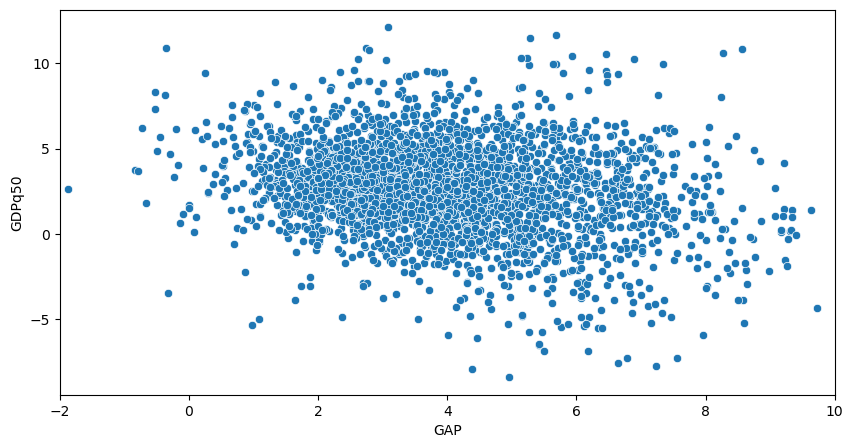

In [92]:
# plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax = sns.scatterplot(data=frontier_data, x='GAP', y='GDPq50', ax=ax)
scatter_lims = (ax.get_xlim(), ax.get_ylim())
ax.set_xlim((-2, 10))
plt.show()

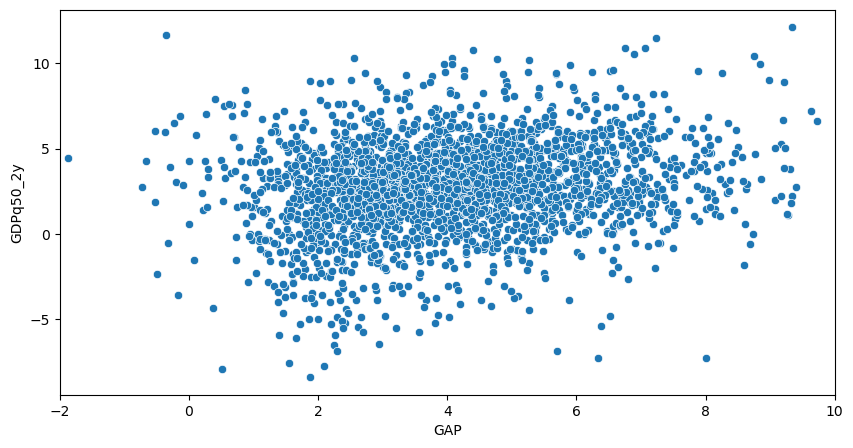

In [93]:
# plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax = sns.scatterplot(data=frontier_data, x='GAP', y='GDPq50_2y', ax=ax)
scatter_lims = (ax.get_xlim(), ax.get_ylim())
ax.set_xlim((-2, 10))
plt.show()

## estimation

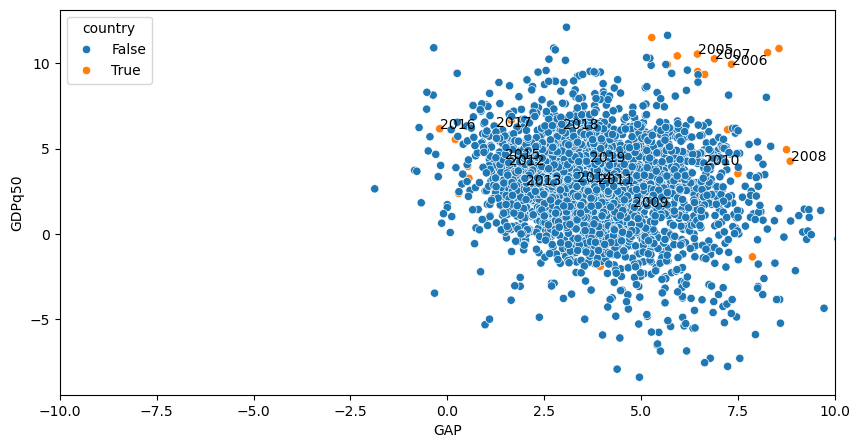

In [62]:
years = ('2005', '2019')
country = 'Armenia'
q_names = {
    'GDP_real_hz_4_growth_pred_qr10': 'GDPq10', 
    'GDP_real_hz_4_growth_pred_qr50': 'GDPq50', 
}
frontier_data = panel_pred_qr.copy()
frontier_data.rename(columns=q_names, inplace=True)
frontier_data['GAP'] = frontier_data['GDPq50'] - frontier_data['GDPq10']
frontier_data.drop(columns='GDPq10', inplace=True)

# Calc 2 year lag frontier data
date_filter = (frontier_data.reset_index()['date'] >= years[0]) & (frontier_data.reset_index()['date'] <= years[1])
date_filter.index = frontier_data.index
frontier_data = frontier_data[date_filter].copy()
country_on_frontier = (frontier_data.reset_index()['country'] == country)
country_on_frontier_labels = frontier_data.index.get_level_values('date')[country_on_frontier]
frontier_data = frontier_data.reset_index(drop=True)

# plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax = sns.scatterplot(data=frontier_data, x='GAP', y='GDPq50', hue=country_on_frontier, ax=ax)
scatter_lims = (ax.get_xlim(), ax.get_ylim())
ax.set_xlim((-10, 10))
label_points(frontier_data[country_on_frontier]["GAP"][::4], 
             frontier_data[country_on_frontier]["GDPq50"][::4], 
             pd.Series(country_on_frontier_labels.year, dtype='str')[::4], ax)
plt.show()

In [74]:
# main model
# leaf_size=30
# contamination=0.05
# p=2
lof = LocalOutlierFactor(n_neighbors=40,
                         algorithm='auto',
                         leaf_size=30,
                         contamination=0.1,
                         metric='minkowski',
                         p=2,
                         novelty=True).fit(frontier_data.to_numpy())

# deriving the mesh table for all predictions
feature_meshgrid = np.meshgrid(*[
    np.arange(frontier_data[f].min(), frontier_data[f].max(), 0.01)
    for f in frontier_data
])
mesh_table = pd.DataFrame(
    dict(zip(frontier_data.columns, [f.ravel() for f in feature_meshgrid])))
mesh_pred = lof.predict(mesh_table).reshape(feature_meshgrid[0].shape)
cluster = pd.Series(lof.predict(frontier_data), name='cluster')

# Smoothing the predictions
# mesh_gaussian_smoothed_pred = gaussian_filter(mesh_pred, sigma=1)
# mesh_mean_smoothed_pred = uniform_filter(mesh_pred, size=5)
# mesh_median_smoothed_pred = median_filter(mesh_pred, size=5)
mesh_threshold_smoothed_pred = threshold_local(mesh_pred, block_size=11)
mesh_table['pred'] = mesh_threshold_smoothed_pred.ravel()

# Deriving boundary points
mesh_table['bounds'] = (1 - np.abs(mesh_table['pred'])).round()

# selecting the frontier points
frontier_points = mesh_table.groupby('GAP').apply(lambda x: x.loc[x['bounds'] != 0, 'GDPq50'].max())
frontier_points = frontier_points.reset_index(name='GDPq50').dropna().drop_duplicates()

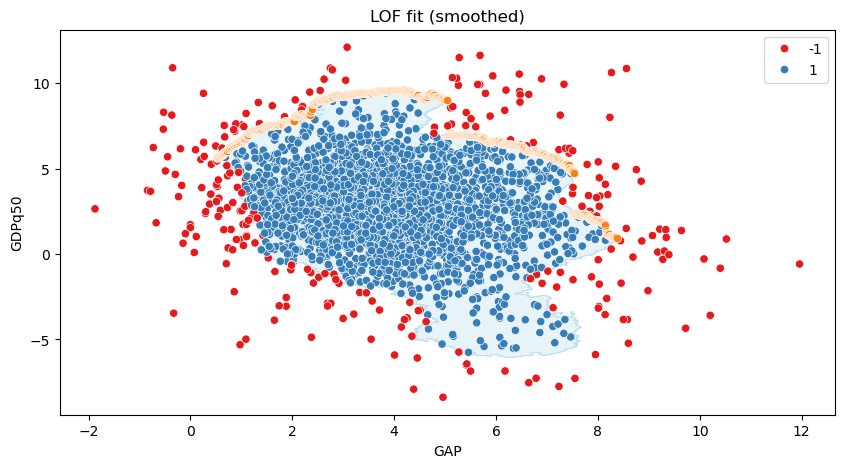

In [75]:
# Create the plots
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Plot the decision boundary
ax.contourf(feature_meshgrid[1],
            feature_meshgrid[0],
            mesh_threshold_smoothed_pred,
            alpha=0.3,
            cmap=ListedColormap(['white', 'lightblue']))
sns.scatterplot(data=frontier_data,
                x='GAP',
                y='GDPq50',
                hue=cluster,
                palette="Set1",
                ax=ax)
sns.scatterplot(data=frontier_points, x='GAP', y='GDPq50', ax=ax)
ax.set_xlim(scatter_lims[0])
ax.set_ylim(scatter_lims[1])
ax.title.set_text('LOF fit (smoothed)')
plt.show()

In [83]:
# fit a polynomial the frontier points
frontier_fit, frontier_model = poly_fit(frontier_points['GAP'], 
                                        frontier_points['GDPq50'],
                                        max_degree=4,
                                        R2_tol=0.005
                                       )
frontier_points['pred'] = frontier_fit
frontier_points['equation'] = polynomial_equation(frontier_model.coef_[::-1])

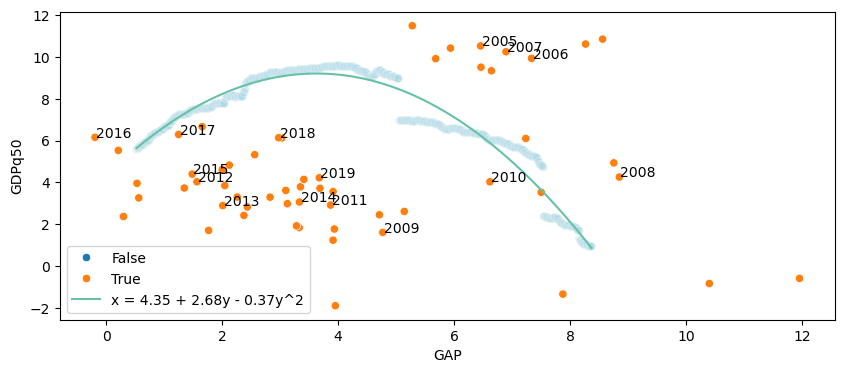

In [90]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.scatterplot(data=frontier_data[country_on_frontier],
                x='GAP',
                y='GDPq50',
                hue=country_on_frontier,
                ax=ax)
sns.lineplot(data=frontier_points,
             x='GAP',
             y='pred',
             hue='equation',
             palette="Set2",
             ax=ax)
sns.scatterplot(data=frontier_points,
                x='GAP',
                y='GDPq50',
                alpha=0.3,
                color='lightblue',
                ax=ax)
label_points(frontier_data[country_on_frontier]["GAP"][::4], 
             frontier_data[country_on_frontier]["GDPq50"][::4], 
             pd.Series(country_on_frontier_labels.year, dtype='str')[::4], ax)
plt.show()